In [8]:
import os
os.environ['TF_ENABLE_ONEDNN_OPTS']= '0'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import keras as kr
from keras.callbacks import EarlyStopping



In [9]:
set_date_antrenare = kr.utils.image_dataset_from_directory(
    'D:/Licenta/DataSetOrganized/data/train',
    labels="inferred",
    label_mode="int",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(256, 256),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
    data_format=None,
    format="tf",
    verbose=True,
)

set_date_validare = kr.utils.image_dataset_from_directory(
    'D:/Licenta/DataSetOrganized/data/validation',
    labels="inferred",
    label_mode="int",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(256, 256),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
    data_format=None,
    format="tf",
    verbose=True,
)


Found 3200 files belonging to 5 classes.
Found 400 files belonging to 5 classes.


In [10]:
model_data_augumentation = kr.Sequential([kr.layers.RandomFlip("horizontal_and_vertical"),kr.layers.RandomZoom(0.2),kr.layers.RandomRotation(0.2),kr.layers.RandomBrightness(0.1)])

In [14]:
model_antrenare = kr.models.Sequential()

model_antrenare.add(kr.layers.Input(shape=(256,256,3)))
model_antrenare.add(model_data_augumentation)
model_antrenare.add(kr.layers.Rescaling(1./255))

model_antrenare.add(kr.layers.Conv2D(filters=64, kernel_size= 3, padding='same'))
model_antrenare.add(kr.layers.BatchNormalization())
model_antrenare.add(kr.layers.Activation('relu'))
model_antrenare.add(kr.layers.MaxPooling2D(pool_size=2,strides=2))

model_antrenare.add(kr.layers.Conv2D(filters=128, kernel_size= 3, padding='same'))
model_antrenare.add(kr.layers.BatchNormalization())
model_antrenare.add(kr.layers.Activation('relu'))
model_antrenare.add(kr.layers.MaxPooling2D(pool_size=2,strides=2))

model_antrenare.add(kr.layers.Conv2D(filters=256, kernel_size= 3, padding='same'))
model_antrenare.add(kr.layers.BatchNormalization())
model_antrenare.add(kr.layers.Activation('relu'))
model_antrenare.add(kr.layers.MaxPooling2D(pool_size=2,strides=2))

model_antrenare.add(kr.layers.Conv2D(filters=512, kernel_size= 3, padding='same'))
model_antrenare.add(kr.layers.BatchNormalization())
model_antrenare.add(kr.layers.Activation('relu'))
model_antrenare.add(kr.layers.MaxPooling2D(pool_size=2,strides=2))

model_antrenare.add(kr.layers.GlobalAveragePooling2D())

model_antrenare.add(kr.layers.Dense(128, activation='relu',kernel_regularizer=kr.regularizers.l2(0.001)))
model_antrenare.add(kr.layers.Dropout(0.5))

model_antrenare.add(kr.layers.Dense(5, activation='softmax'))

model_antrenare.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy',metrics=['accuracy'])

reduce_lr = kr.callbacks.ReduceLROnPlateau(monitor='val_loss', actor=0.2,patience=5,min_lr=0.000001,verbose=1)

early_stop = kr.callbacks.EarlyStopping(monitor='val_loss', patience=20, verbose=1,restore_best_weights=True)

model_antrenare.summary()


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_3 (Rescaling)         │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 256, 256, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 256, 256, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 256, 256, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 128, 128, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 128, 128, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_12 (Activation)      │ (None, 128, 128, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 64, 64, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 64, 64, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_13 (Activation)      │ (None, 64, 64, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 32, 32, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 32, 32, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_14 (Activation)      │ (None, 32, 32, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 16, 16, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 1,621,125 (6.18 MB)

 Trainable params: 1,619,205 (6.18 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [15]:
model_antrenare_istoric = model_antrenare.fit(x=set_date_antrenare,validation_data = set_date_validare,epochs=40,callbacks=[early_stop,reduce_lr])

Epoch 1/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 359s 4s/step - accuracy: 0.5391 - loss: 1.3333 - val_accuracy: 0.2000 - val_loss: 4.2323 - learning_rate: 0.0010
Epoch 2/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 326s 3s/step - accuracy: 0.6087 - loss: 1.1587 - val_accuracy: 0.2000 - val_loss: 6.4202 - learning_rate: 0.0010
Epoch 3/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 351s 4s/step - accuracy: 0.6094 - loss: 1.1093 - val_accuracy: 0.2000 - val_loss: 5.9978 - learning_rate: 0.0010
Epoch 4/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 334s 3s/step - accuracy: 0.6366 - loss: 1.0371 - val_accuracy: 0.2000 - val_loss: 5.8462 - learning_rate: 0.0010
Epoch 5/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 331s 3s/step - accuracy: 0.6581 - loss: 0.9937 - val_accuracy: 0.4200 - val_loss: 2.0225 - learning_rate: 0.0010
Epoch 6/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 351s 4s/step - accuracy: 0.6509 - loss: 0.9612 - val_accuracy: 0.4600 - val_loss: 1.7922 - learning_rate: 0.0010
Epoch 7/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 357s 4s/step - accuracy: 0.6794 - loss: 0.

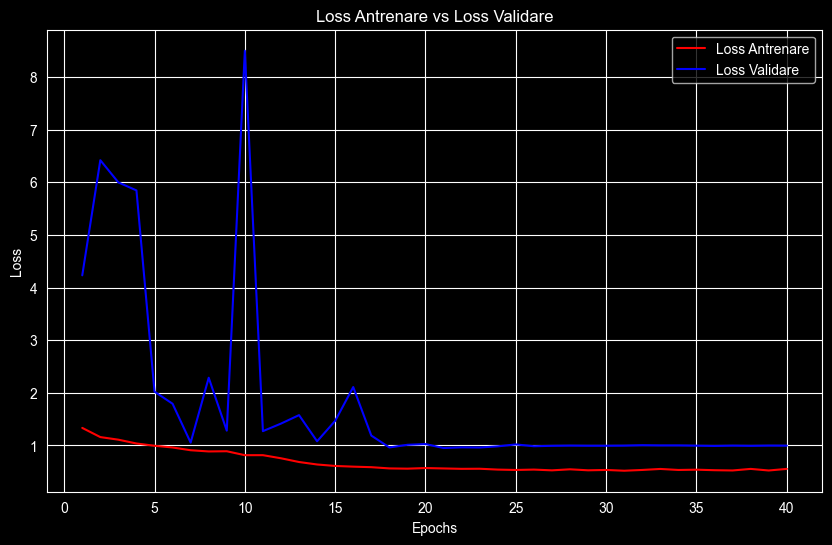

In [16]:
loss = model_antrenare_istoric.history['loss']
val_loss = model_antrenare_istoric.history['val_loss']
epochs = range(1, len(loss) + 1)


plt.figure(figsize = (10,6))
plt.plot(epochs, loss, 'r', label='Loss Antrenare')
plt.plot(epochs, val_loss, 'b', label='Loss Validare')
plt.title('Loss Antrenare vs Loss Validare')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

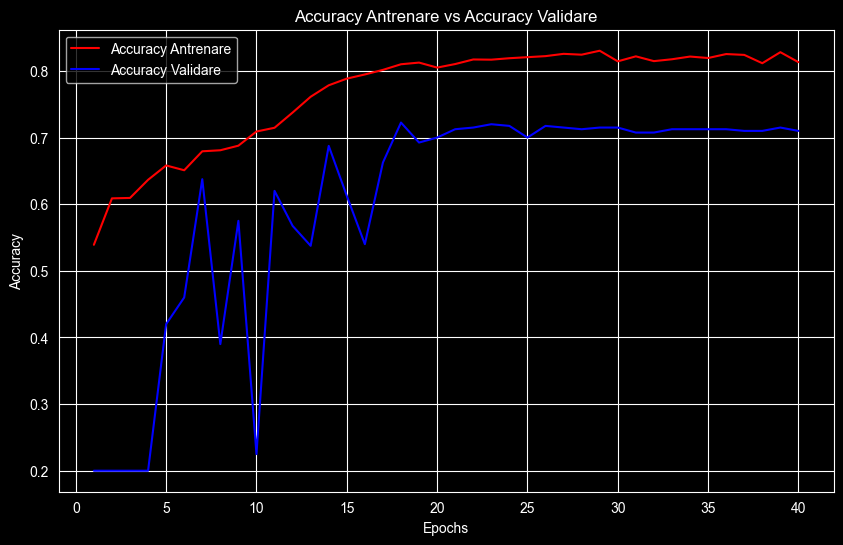

In [17]:
accuracy = model_antrenare_istoric.history['accuracy']
val_accuracy = model_antrenare_istoric.history['val_accuracy']
epochs = range(1, len(accuracy) + 1)


plt.figure(figsize = (10,6))
plt.plot(epochs, accuracy, 'r', label='Accuracy Antrenare')
plt.plot(epochs, val_accuracy, 'b', label='Accuracy Validare')
plt.title('Accuracy Antrenare vs Accuracy Validare')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show()